In [47]:
import sys

sys.path.append("..")

from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import random
from pulp import *
import cma

In [48]:
from candidate.candidate import Candidate
from voter.voter import Voter
from election.election import Election
from election.result import ElectionResult
from analysis.analyzer import ResultsAnalyzer

from strategy.strategy import VotingStrategy
from strategy.plurality import PluralityStrategy
from strategy.borda import BordaCountStrategy
from strategy.veto import VetoStrategy

from visualization.util import (
    plot,
    plot_results,
    random_2d_points,
    random_2d_point,
    plot_winner_distance_histogram,
    plot_lp_result,
    plot_lp_swap_result,
)

from calculation.calculation import find_farthest_pair, find_farthest_triple

from lp.lp import PermutationLpModel, exclude_current_solution, exclude_largest_variable

In [49]:
# https://claude.ai/share/38d5e708-a9f6-456d-b1f1-69be59d9f84c

Genom to ciąg liczb opisujących całe wybory. Genom składa się z dwóch częsci.
1. $m$ kandydatów, dla każdego para współrzędnych $(x,y)$, więc razem $2m$ zmiennych
2. $G$ skupisk, gdzie każde skupisko opisane jest czterema liczbami: położeniem środka $(x,y)$, rozrzutem i wagą. Łącznie $4G$ zmiennych.

Łącznie jeden genom jest $(2m+4G)$ wymiarowy.

In [50]:
@dataclass
class GenomeConfig:
    n_candidates: int
    n_clusters: int
    bounds_x: tuple[float, float] = (-10.0, 10.0)
    bounds_y: tuple[float, float] = (-10.0, 10.0)
    spread_bounds: tuple[float, float] = (0.5, 5.0)
    weight_bounds: tuple[float, float] = (0.0, 1.0)

    @property
    def genome_length(self) -> int:
        return 2 * self.n_candidates + 4 * self.n_clusters

    @property
    def lower_bounds(self) -> list[float]:
        candidate_lb = [self.bounds_x[0], self.bounds_y[0]] * self.n_candidates
        cluster_lb = [
            self.bounds_x[0],
            self.bounds_y[0],
            self.spread_bounds[0],
            self.weight_bounds[0],
        ] * self.n_clusters
        return candidate_lb + cluster_lb

    @property
    def upper_bounds(self) -> list[float]:
        candidate_ub = [self.bounds_x[1], self.bounds_y[1]] * self.n_candidates
        cluster_ub = [
            self.bounds_x[1],
            self.bounds_y[1],
            self.spread_bounds[1],
            self.weight_bounds[1],
        ] * self.n_clusters
        return candidate_ub + cluster_ub

    def random_genome(self, rng: np.random.Generator) -> np.ndarray:
        lb = np.array(self.lower_bounds)
        ub = np.array(self.upper_bounds)
        return lb + rng.random(self.genome_length) * (ub - lb)


@dataclass
class VoterCluster:
    center: tuple[float, float]
    spread: float
    weight: float


def decode_genome(
    genome: np.ndarray, config: GenomeConfig
) -> tuple[list[Candidate], list[VoterCluster]]:
    genome = np.asarray(genome)
    n_candidate_genes = 2 * config.n_candidates

    candidate_genes = genome[:n_candidate_genes]
    candidates = [
        Candidate(id=i, position=(candidate_genes[2 * i], candidate_genes[2 * i + 1]))
        for i in range(config.n_candidates)
    ]

    cluster_genes = genome[n_candidate_genes:]
    clusters = [
        VoterCluster(
            center=(cluster_genes[4 * g], cluster_genes[4 * g + 1]),
            spread=max(cluster_genes[4 * g + 2], 1e-3),
            weight=max(cluster_genes[4 * g + 3], 0.0),
        )
        for g in range(config.n_clusters)
    ]

    return candidates, clusters


def generate_voters(
    clusters: list[VoterCluster], n_voters: int, rng: np.random.Generator
) -> list[Voter]:
    weights = np.array([c.weight for c in clusters])
    if weights.sum() <= 0:
        weights = np.ones(len(clusters))
    probs = weights / weights.sum()

    cluster_choices = rng.choice(len(clusters), size=n_voters, p=probs)
    voters = []
    for idx in cluster_choices:
        cluster = clusters[idx]
        position = rng.normal(loc=cluster.center, scale=cluster.spread, size=2)
        voters.append(Voter(position=position))
    return voters


Rozważ odporniejszą metrykę - np. karę za kandydatów na brzegu albo niezgodę względem rozrzutu kandydatów - żeby optimum nie było po prostu "rogi planszy".

In [51]:
# Objective functions for the CMA-ES search. Each maps an ElectionResult to a
# scalar to MAXIMISE.


def _mean_pairwise(points: np.ndarray) -> float:
    """Average Euclidean distance over all unordered pairs of points."""
    if len(points) < 2:
        return 0.0
    d = np.linalg.norm(points[:, None, :] - points[None, :, :], axis=2)
    return float(d[np.triu_indices(len(points), k=1)].mean())


def _spread(points: np.ndarray) -> float:
    """Scale proxy: RMS distance to the centroid. O(n), so cheap for many voters."""
    if len(points) < 2:
        return 0.0
    return float(np.sqrt(((points - points.mean(axis=0)) ** 2).sum(axis=1).mean()))


def winner_disagreement(result: ElectionResult) -> float:
    """Original objective: mean pairwise distance between the rules' winners. Its
    optimum is degenerate -- it just pushes candidates to the board corners."""
    winners = np.array([w.position for w in result.winners().values()])
    return _mean_pairwise(winners)


def relative_winner_disagreement(
    result: ElectionResult, denominator: str = "voters", eps: float = 1e-9
) -> float:
    """Scale-free disagreement: winner spread divided by the field's spread, so
    blowing everything up to the corners no longer helps (the ratio is homogeneous
    of degree 0). The optimiser must make winners far apart *relative* to the field.

    denominator: "voters" (spread of the electorate; hardest to game) or
                 "candidates" (spread of the candidate field).
    """
    winners = np.array([w.position for w in result.winners().values()])
    numerator = _mean_pairwise(winners)
    if denominator == "candidates":
        field = np.array([c.position for c in result.candidates])
    else:
        field = np.array([v.position for v in result.voters])
    return numerator / (_spread(field) + eps)

def distinct_winner_objective(result: ElectionResult) -> float:
    """Reward the strategies picking *different* winners.

    Rules whose top score is tied are dropped - their "winner" would be an
    arbitrary id-order tie-break (e.g. Veto on a one-sided electorate). The
    integer count of distinct winners dominates; a continuous winner-spread term,
    scaled into [0, 1) by the candidate field, gives CMA-ES a gradient toward
    separating one more rule (a bare integer count would be flat / unoptimisable).
    """
    clean = [t for t in result.tallies.values() if not t.is_tie()]
    winners = [t.winner(result.candidates) for t in clean]
    n_distinct = len({w.id for w in winners})

    win_pos = np.array([w.position for w in winners]) if winners else np.empty((0, 2))
    cand_pos = np.array([c.position for c in result.candidates])
    cand_dist = np.linalg.norm(cand_pos[:, None, :] - cand_pos[None, :, :], axis=2)
    shaping = _mean_pairwise(win_pos) / (cand_dist.max() + 1e-9)
    return n_distinct + min(shaping, 0.999)

In [52]:
def _min_candidate_gap(result: ElectionResult) -> float:
    """Distance between the two closest candidates."""
    pos = np.array([c.position for c in result.candidates])
    d = np.linalg.norm(pos[:, None, :] - pos[None, :, :], axis=2)
    return float(d[np.triu_indices(len(pos), k=1)].min())


def with_candidate_spacing(objective, min_dist: float = 1.5):
    """Wrap an objective with a multiplicative spacing gate. The score is scaled by
    min(1, closest_candidate_gap / min_dist): stacked candidates (clones) drive it
    toward 0, with a smooth gradient to spread them apart. No weight to tune -- the
    factor lives in [0, 1]. Composes with any objective.
    """
    def wrapped(result: ElectionResult) -> float:
        factor = min(1.0, _min_candidate_gap(result) / min_dist)
        return objective(result) * factor

    return wrapped


# Ready-to-use: distinct winners, but penalising stacked candidates (clones).
spaced_distinct_objective = with_candidate_spacing(distinct_winner_objective, min_dist=1.5)

In [53]:
def evaluate_genome(
    genome: np.ndarray,
    config: GenomeConfig,
    strategies: list[VotingStrategy],
    n_voters: int,
    rng: np.random.Generator,
    n_reps: int = 1,
    objective=relative_winner_disagreement,
) -> float:
    """Averaging denoises the stochastic fitness so the optimizer ranks
    genomes by their *true* value, not by a lucky voter sample."""
    candidates, clusters = decode_genome(genome, config)
    scores = []
    for _ in range(n_reps):
        voters = generate_voters(clusters, n_voters, rng)
        result = Election(candidates, voters).compare_strategies(strategies)
        scores.append(objective(result))
    return float(np.mean(scores))


class EvolutionaryElection:
    def __init__(
        self,
        config: GenomeConfig,
        strategies: list[VotingStrategy],
        n_voters: int = 200,
        sigma0: float = 2.0,
        seed: int | None = None,
        popsize: int | None = None,
        n_reps: int = 3,
        objective=relative_winner_disagreement,
    ):
        self.config = config
        self.strategies = strategies
        self.n_voters = n_voters
        self.n_reps = n_reps
        self.objective = objective
        self.rng = np.random.default_rng(seed)

        x0 = config.random_genome(self.rng)
        ranges = np.array(config.upper_bounds) - np.array(config.lower_bounds)
        opts = {
            "bounds": [config.lower_bounds, config.upper_bounds],
            "seed": seed if seed is not None else np.nan,
            # Per-dimension scale so a single sigma0 makes sense across genes with
            # very different ranges (positions vs. spread vs. weight).
            "CMA_stds": (ranges / ranges.max()).tolist(),
        }
        if popsize is not None:
            opts["popsize"] = popsize

        self.es = cma.CMAEvolutionStrategy(x0, sigma0, opts)
        self.history: list[float] = []

    def _fitness(self, genome: np.ndarray) -> float:
        score = evaluate_genome(
            genome,
            self.config,
            self.strategies,
            self.n_voters,
            self.rng,
            self.n_reps,
            self.objective,
        )
        # cma minimizes, but we want to maximize the disagreement between strategies
        return -score

    def step(self) -> float:
        solutions = self.es.ask()
        fitnesses = [self._fitness(np.array(x)) for x in solutions]
        self.es.tell(solutions, fitnesses)
        best = -min(fitnesses)
        self.history.append(best)
        return best

    def run(self, n_generations: int = 50, verbose: bool = False) -> np.ndarray:
        for gen in range(n_generations):
            best = self.step()
            if verbose:
                print(f"gen {gen:3d}: best objective = {best:.4f}")
        return self.best_genome()

    def best_genome(self) -> np.ndarray:
        return np.array(self.es.result.xbest)

    def best_election(self) -> Election:
        candidates, clusters = decode_genome(self.best_genome(), self.config)
        voters = generate_voters(clusters, self.n_voters, self.rng)
        return Election(candidates, voters)

In [54]:
config = GenomeConfig(n_candidates=5, n_clusters=4)
strategies = [PluralityStrategy(), BordaCountStrategy(), VetoStrategy()]

evo = EvolutionaryElection(
    config,
    strategies,
    n_voters=1000,
    sigma0=2.0,
    objective=relative_winner_disagreement,  # scale-free; use winner_disagreement to revert
)
evo.run(n_generations=40, verbose=True)

best_election = evo.best_election()
best_result = best_election.compare_strategies(strategies, label="best genome")
best_result.winners()

(6_w,13)-aCMA-ES (mu_w=4.0,w_1=38%) in dimension 26 (seed=nan, Mon Jun 22 15:19:08 2026)
gen   0: best objective = 1.5313
gen   1: best objective = 1.4246
gen   2: best objective = 1.4261
gen   3: best objective = 1.5704
gen   4: best objective = 1.5152
gen   5: best objective = 1.7240
gen   6: best objective = 1.4157
gen   7: best objective = 1.6875
gen   8: best objective = 1.8027
gen   9: best objective = 1.5226
gen  10: best objective = 1.6572
gen  11: best objective = 1.8981
gen  12: best objective = 1.8750
gen  13: best objective = 1.8508
gen  14: best objective = 1.8438
gen  15: best objective = 1.7432
gen  16: best objective = 1.9254
gen  17: best objective = 2.0734
gen  18: best objective = 1.8833
gen  19: best objective = 2.3794
gen  20: best objective = 2.5734
gen  21: best objective = 2.7361
gen  22: best objective = 2.5697
gen  23: best objective = 2.7151
gen  24: best objective = 2.5579
gen  25: best objective = 2.4971
gen  26: best objective = 2.2602
gen  27: best object

{'plurality': Candidate(id=2, position=(np.float64(-8.974442770271937), np.float64(8.297339182442677))),
 'borda': Candidate(id=2, position=(np.float64(-8.974442770271937), np.float64(8.297339182442677))),
 'veto': Candidate(id=3, position=(np.float64(7.206808823609934), np.float64(-9.891523076967564)))}

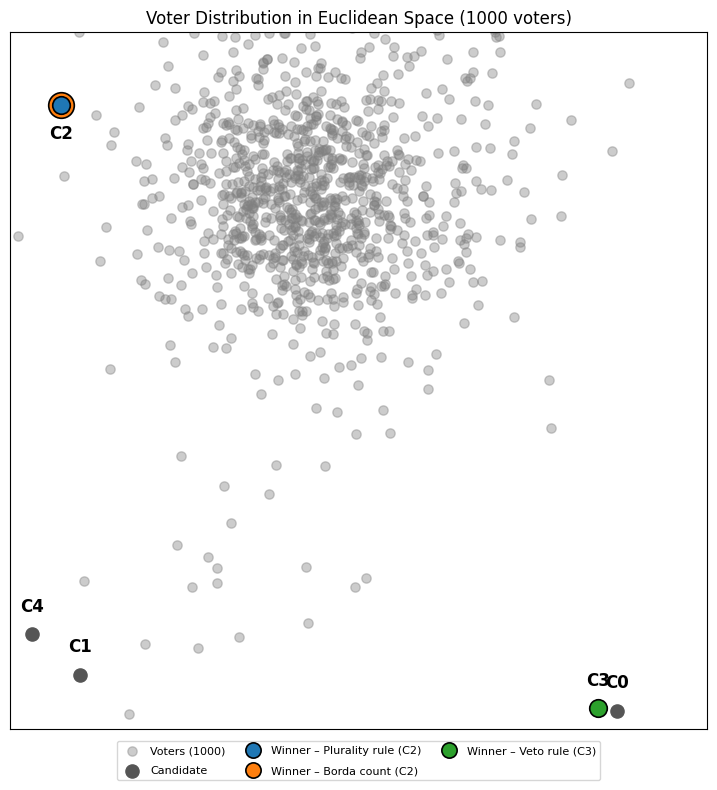

In [55]:
plot_results(best_result)

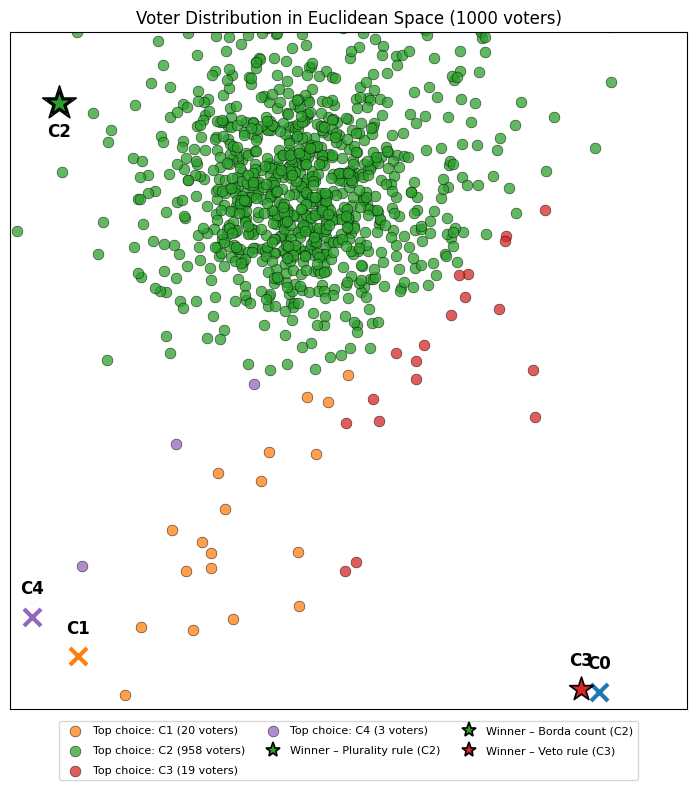

In [56]:
plot_results(best_result, color_voters=True)

In [57]:
config = GenomeConfig(n_candidates=5, n_clusters=4)
strategies = [PluralityStrategy(), BordaCountStrategy(), VetoStrategy()]

evo = EvolutionaryElection(
    config,
    strategies,
    n_voters=1000,
    sigma0=2.0,
    objective=relative_winner_disagreement,  # scale-free; use winner_disagreement to revert
)
evo.run(n_generations=250, verbose=True)

best_election = evo.best_election()
best_result = best_election.compare_strategies(strategies, label="best genome")
best_result.winners()

(6_w,13)-aCMA-ES (mu_w=4.0,w_1=38%) in dimension 26 (seed=nan, Mon Jun 22 15:19:33 2026)
gen   0: best objective = 2.3528
gen   1: best objective = 1.8471
gen   2: best objective = 2.3473
gen   3: best objective = 2.4034
gen   4: best objective = 2.2996
gen   5: best objective = 2.6368
gen   6: best objective = 2.9439
gen   7: best objective = 2.7380
gen   8: best objective = 3.4008
gen   9: best objective = 3.5858
gen  10: best objective = 2.9153
gen  11: best objective = 2.9765
gen  12: best objective = 2.9089
gen  13: best objective = 2.8556
gen  14: best objective = 3.1357
gen  15: best objective = 3.2460
gen  16: best objective = 3.3988
gen  17: best objective = 3.8989
gen  18: best objective = 4.2044
gen  19: best objective = 4.0879
gen  20: best objective = 4.2513
gen  21: best objective = 4.3743
gen  22: best objective = 4.7111
gen  23: best objective = 4.4842
gen  24: best objective = 5.3647
gen  25: best objective = 6.2674
gen  26: best objective = 5.8762
gen  27: best object

{'plurality': Candidate(id=3, position=(np.float64(-9.999993668336865), np.float64(-9.956415310452101))),
 'borda': Candidate(id=3, position=(np.float64(-9.999993668336865), np.float64(-9.956415310452101))),
 'veto': Candidate(id=0, position=(np.float64(9.933780019699507), np.float64(9.449710091845319)))}

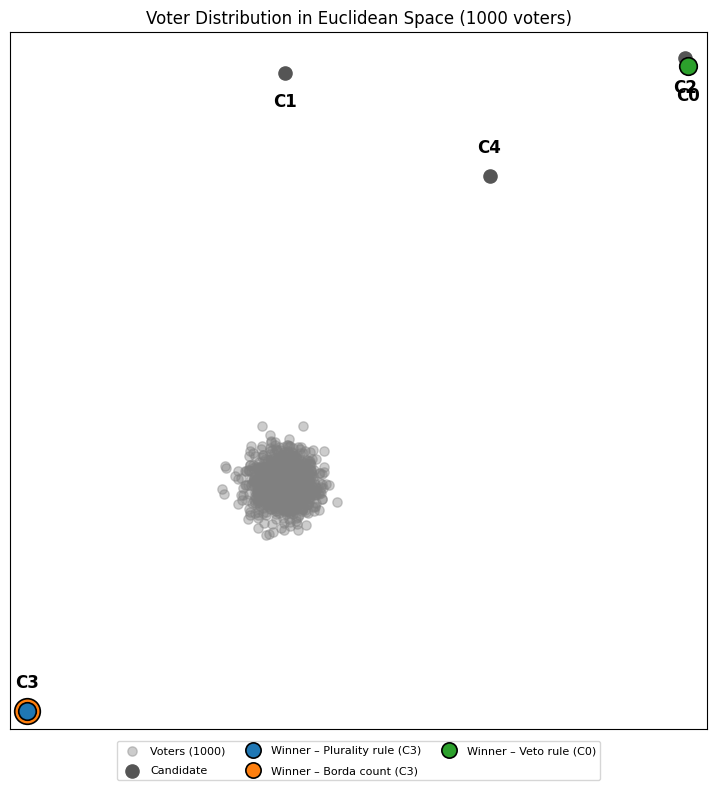

In [58]:
plot_results(best_result)

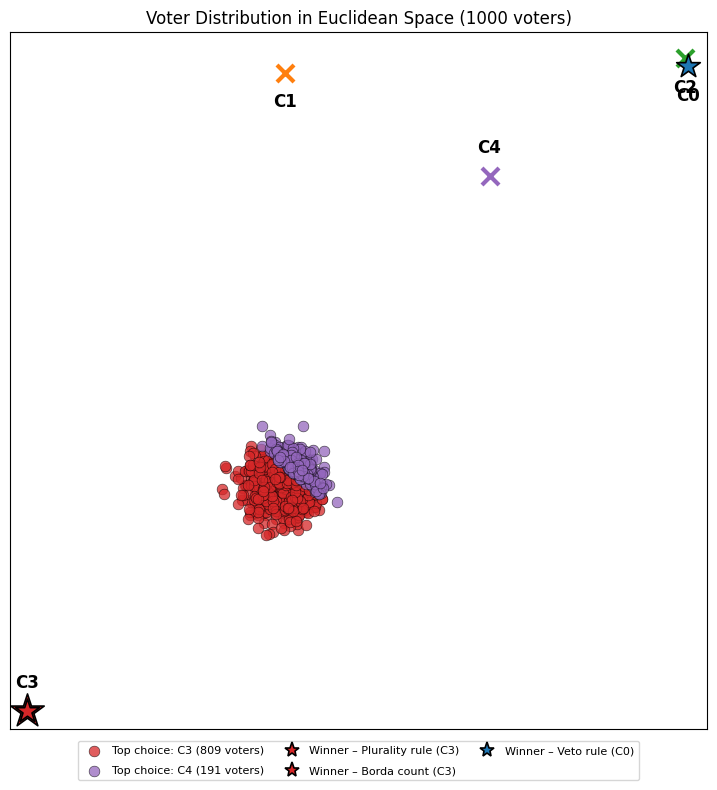

In [59]:
plot_results(best_result, color_voters=True)

In [60]:
config = GenomeConfig(n_candidates=5, n_clusters=4)
strategies = [PluralityStrategy(), BordaCountStrategy(), VetoStrategy()]

evo = EvolutionaryElection(
    config,
    strategies,
    n_voters=1000,
    sigma0=2.0,
    objective=distinct_winner_objective,
)
evo.run(n_generations=250, verbose=True)

best_election = evo.best_election()
best_result = best_election.compare_strategies(strategies, label="best genome")
best_result.winners()

(6_w,13)-aCMA-ES (mu_w=4.0,w_1=38%) in dimension 26 (seed=nan, Mon Jun 22 15:22:09 2026)
gen   0: best objective = 2.4581
gen   1: best objective = 2.5472
gen   2: best objective = 2.6468
gen   3: best objective = 2.6538
gen   4: best objective = 2.6176
gen   5: best objective = 3.6607
gen   6: best objective = 2.6435
gen   7: best objective = 2.6062
gen   8: best objective = 2.6142
gen   9: best objective = 2.6367
gen  10: best objective = 2.6512
gen  11: best objective = 2.6313
gen  12: best objective = 2.6405
gen  13: best objective = 3.6813
gen  14: best objective = 2.6104
gen  15: best objective = 2.5976
gen  16: best objective = 2.8202
gen  17: best objective = 3.6523
gen  18: best objective = 3.6916
gen  19: best objective = 2.6519
gen  20: best objective = 2.6470
gen  21: best objective = 2.6585
gen  22: best objective = 2.6506
gen  23: best objective = 2.6525
gen  24: best objective = 2.6311
gen  25: best objective = 2.6476
gen  26: best objective = 2.6552
gen  27: best object

{'plurality': Candidate(id=1, position=(np.float64(-8.839391047755594), np.float64(-2.0088365285410634))),
 'borda': Candidate(id=4, position=(np.float64(7.906212251990356), np.float64(-9.55272699244991))),
 'veto': Candidate(id=2, position=(np.float64(6.082999214019007), np.float64(8.703295103700258)))}

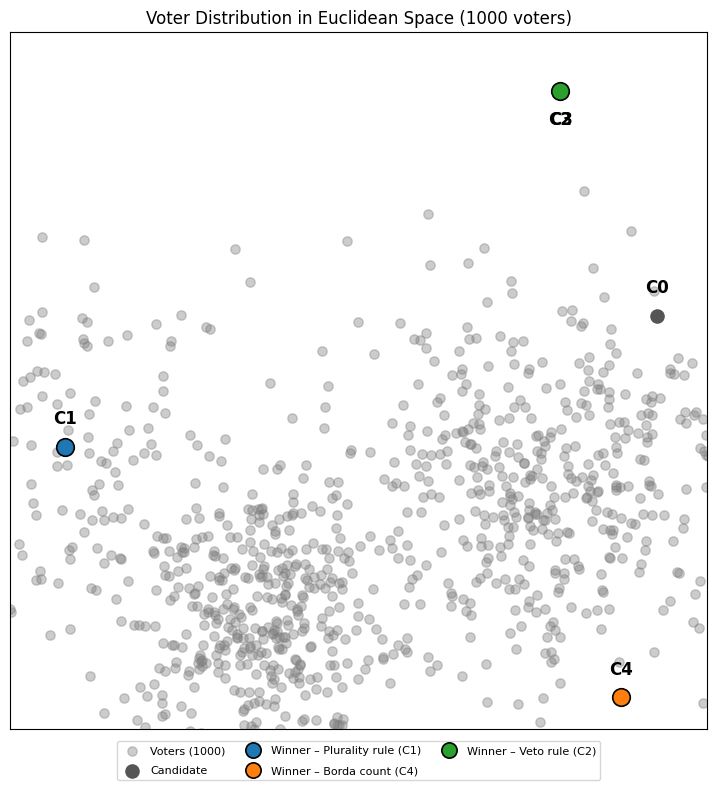

In [61]:
plot_results(best_result)

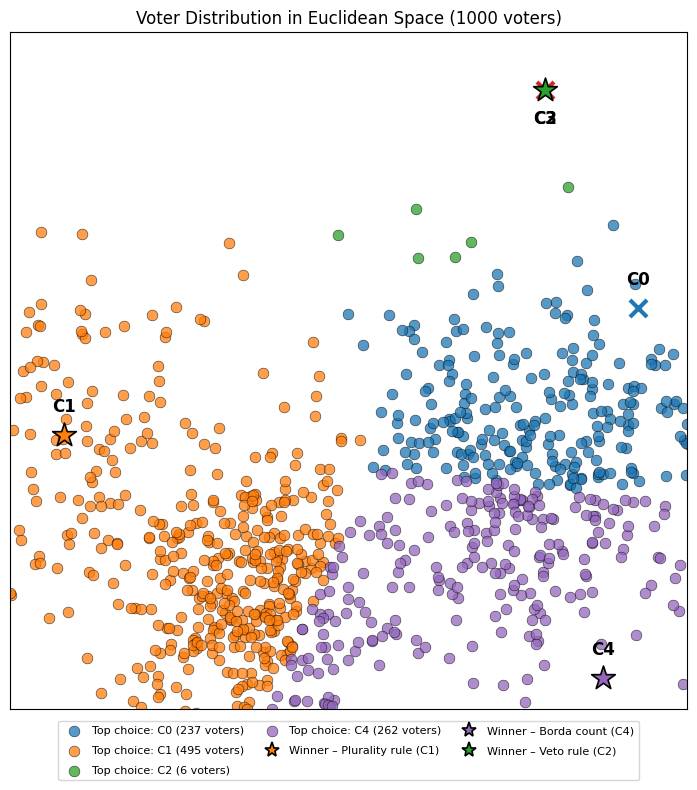

In [62]:
plot_results(best_result, color_voters=True)

In [63]:
config = GenomeConfig(n_candidates=5, n_clusters=4)
strategies = [PluralityStrategy(), BordaCountStrategy(), VetoStrategy()]

evo = EvolutionaryElection(
    config,
    strategies,
    n_voters=1000,
    sigma0=2.0,
    objective=spaced_distinct_objective,
)
evo.run(n_generations=250, verbose=True)

best_election = evo.best_election()
best_result = best_election.compare_strategies(strategies, label="best genome")
best_result.winners()

(6_w,13)-aCMA-ES (mu_w=4.0,w_1=38%) in dimension 26 (seed=nan, Mon Jun 22 15:24:38 2026)
gen   0: best objective = 2.7056
gen   1: best objective = 3.3784
gen   2: best objective = 3.4433
gen   3: best objective = 3.7290
gen   4: best objective = 3.6956
gen   5: best objective = 3.8142
gen   6: best objective = 3.6732
gen   7: best objective = 3.7432
gen   8: best objective = 3.8363
gen   9: best objective = 3.8838
gen  10: best objective = 3.7475
gen  11: best objective = 3.7934
gen  12: best objective = 3.8517
gen  13: best objective = 3.8295
gen  14: best objective = 3.8213
gen  15: best objective = 3.8602
gen  16: best objective = 3.8367
gen  17: best objective = 3.8166
gen  18: best objective = 3.7896
gen  19: best objective = 3.8695
gen  20: best objective = 3.8385
gen  21: best objective = 3.8526
gen  22: best objective = 3.8697
gen  23: best objective = 3.7698
gen  24: best objective = 3.7387
gen  25: best objective = 3.7623
gen  26: best objective = 3.6600
gen  27: best object

{'plurality': Candidate(id=4, position=(np.float64(-9.967590874908169), np.float64(-9.78755321982689))),
 'borda': Candidate(id=1, position=(np.float64(-1.7305119063363237), np.float64(8.747591972062306))),
 'veto': Candidate(id=3, position=(np.float64(9.7254542870515), np.float64(-7.998090871485786)))}

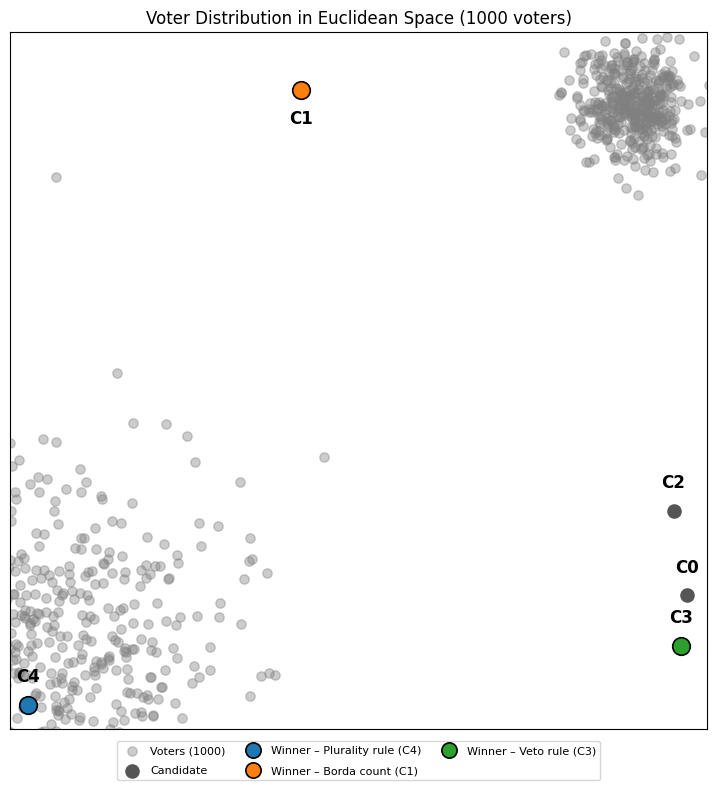

In [64]:
plot_results(best_result)

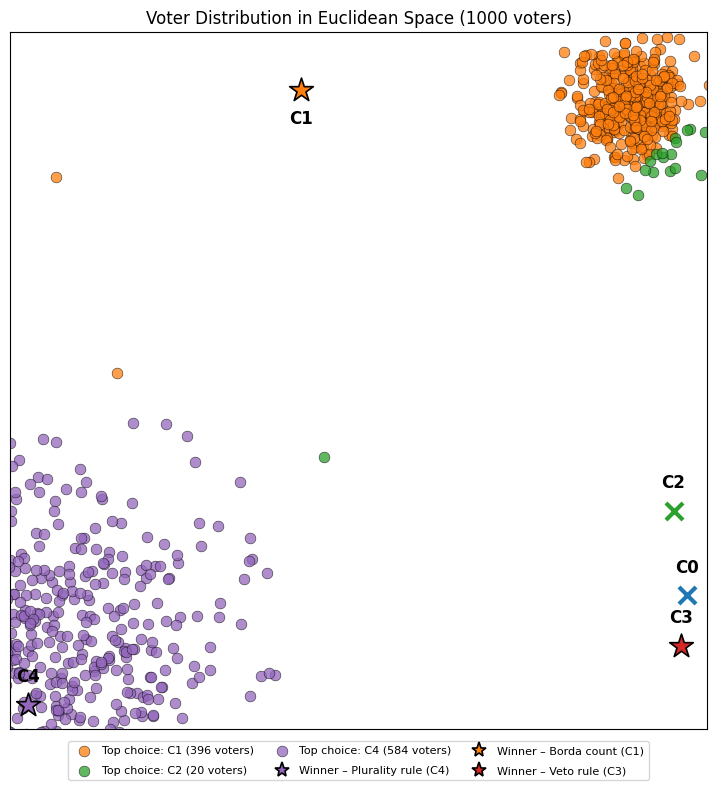

In [65]:
plot_results(best_result, color_voters=True)

In [66]:
# Compare CMA-ES against random search at an EQUAL evaluation budget, and re-evaluate
# both winners honestly (many fresh voter draws) to strip the noise advantage.

OBJECTIVE = relative_winner_disagreement
N_VOTERS_CMP = 1000
N_REPS_CMP = 3
N_GEN_CMP = 100  # keep modest; this cell may take a little while

# --- CMA-ES: record observed best-so-far per evaluation and sigma per gen ---
evo_cmp = EvolutionaryElection(
    config, strategies, n_voters=N_VOTERS_CMP, sigma0=2.0,
    objective=OBJECTIVE, n_reps=N_REPS_CMP, seed=0,
)
cma_curve, sigma_hist, best = [], [], -np.inf
for _ in range(N_GEN_CMP):
    solutions = evo_cmp.es.ask()
    fitnesses = []
    for x in solutions:
        s = evaluate_genome(
            np.array(x), config, strategies, N_VOTERS_CMP, evo_cmp.rng, N_REPS_CMP, OBJECTIVE
        )
        fitnesses.append(-s)  # cma minimizes
        best = max(best, s)
        cma_curve.append(best)
    evo_cmp.es.tell(solutions, fitnesses)
    sigma_hist.append(evo_cmp.es.sigma)
cma_best_genome = np.array(evo_cmp.es.result.xbest)
n_evals = len(cma_curve)

# --- Random search with the SAME number of evaluations ---
rng_rs = np.random.default_rng(1)
rs_curve, rs_best, rs_best_genome = [], -np.inf, None
for _ in range(n_evals):
    g = config.random_genome(rng_rs)
    s = evaluate_genome(g, config, strategies, N_VOTERS_CMP, rng_rs, N_REPS_CMP, OBJECTIVE)
    if s > rs_best:
        rs_best, rs_best_genome = s, g
    rs_curve.append(rs_best)

# --- Honest re-evaluation of each winner on many fresh voter draws ---
def honest_scores(genome, n_draws=200):
    rng = np.random.default_rng(2)
    candidates, clusters = decode_genome(genome, config)
    return np.array([
        OBJECTIVE(
            Election(candidates, generate_voters(clusters, N_VOTERS_CMP, rng))
            .compare_strategies(strategies)
        )
        for _ in range(n_draws)
    ])

cma_honest = honest_scores(cma_best_genome)
rs_honest = honest_scores(rs_best_genome)

(6_w,13)-aCMA-ES (mu_w=4.0,w_1=38%) in dimension 26 (seed=154519, Mon Jun 22 15:27:10 2026)


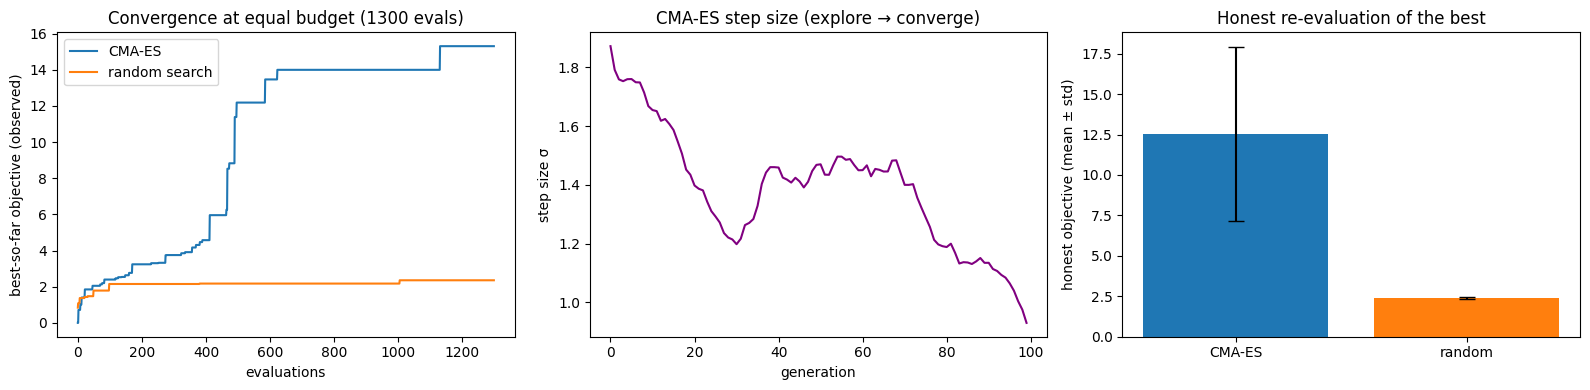

observed best   CMA-ES: 15.303   random: 2.356
honest mean     CMA-ES: 12.538 ± 5.387   random: 2.380 ± 0.064


In [67]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(cma_curve, label="CMA-ES")
axes[0].plot(rs_curve, label="random search")
axes[0].set_xlabel("evaluations")
axes[0].set_ylabel("best-so-far objective (observed)")
axes[0].set_title(f"Convergence at equal budget ({n_evals} evals)")
axes[0].legend()

axes[1].plot(sigma_hist, color="purple")
axes[1].set_xlabel("generation")
axes[1].set_ylabel("step size σ")
axes[1].set_title("CMA-ES step size (explore → converge)")

means = [cma_honest.mean(), rs_honest.mean()]
stds = [cma_honest.std(), rs_honest.std()]
axes[2].bar(["CMA-ES", "random"], means, yerr=stds, capsize=6, color=["tab:blue", "tab:orange"])
axes[2].set_ylabel("honest objective (mean ± std)")
axes[2].set_title("Honest re-evaluation of the best")

plt.tight_layout()
plt.show()

print(f"observed best   CMA-ES: {cma_curve[-1]:.3f}   random: {rs_curve[-1]:.3f}")
print(
    f"honest mean     CMA-ES: {cma_honest.mean():.3f} ± {cma_honest.std():.3f}"
    f"   random: {rs_honest.mean():.3f} ± {rs_honest.std():.3f}"
)